# Retail Sales ETL Pipeline

A small but realistic **data-engineering** project: take a messy raw sales export and
turn it into a clean, typed, analysis-ready dataset.

The reusable pipeline lives in [`src/etl.py`](../src/etl.py) (extract → transform →
load). This notebook walks through *what* it fixes and *why*, with before/after views
and a data-quality audit.

**Raw-data problems handled:** mixed date formats, currency symbols & thousands
separators, inconsistent category/region capitalisation, missing values, negative
quantities and duplicate rows.


In [1]:
import sys, os
sys.path.append("..")           # import the pipeline package
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import etl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Extract — look at the raw mess

In [2]:
raw, products = etl.extract("../data/raw/sales_raw.csv",
                            "../data/raw/products.csv")
print("raw shape:", raw.shape)
raw.head(8)

raw shape: (5080, 7)


,order_id,order_date,product_id,category,region,quantity,revenue
0,104493,20/12/2024,P03,STATIONERY,South,1,$4.20
1,104267,10/11/2024,P01,electronics,North,3,74.97
2,101260,2024-07-27,P05,home,West,7,$103.25
3,100801,30 Apr 2024,P02,electronics,South,7,$66.50
4,103567,2024-04-22,P04,HOME,North,4,128.00
5,103291,27 Aug 2024,P06,home,South,2,16.60
6,103917,11-13-2024,P06,home,West,1,8.30
7,102229,28/09/2024,P07,electronics,West,7,$553.00


In [3]:
print("Date formats are inconsistent:")
print(raw["order_date"].head(6).tolist())
print("\nRevenue is a string with $ and commas:")
print(raw["revenue"].head(6).tolist())
print("\nCategory capitalisation is all over the place:")
print(raw["category"].value_counts().to_dict())

Date formats are inconsistent:
['20/12/2024', '10/11/2024', '2024-07-27', '30 Apr 2024', '2024-04-22', '27 Aug 2024']

Revenue is a string with $ and commas:
['$4.20', '74.97', '$103.25', '$66.50', '128.00', '16.60']

Category capitalisation is all over the place:
{'home': 1285, 'electronics': 1257, 'stationery': 842, 'ELECTRONICS': 555, 'HOME': 545, 'STATIONERY': 352, 'electronics ': 71, 'home ': 58, 'stationery ': 43, 'HOME ': 33, 'ELECTRONICS ': 23, 'STATIONERY ': 16}


In [4]:
print("Data-quality issues in the raw file:")
print(f"  duplicate rows     : {raw.duplicated().sum()}")
print(f"  missing region     : {raw['region'].isna().sum()}")
print(f"  blank revenue      : {(raw['revenue'].astype(str).str.strip()=='').sum()}")
print(f"  non-positive qty   : {(raw['quantity'] <= 0).sum()}")

Data-quality issues in the raw file:
  duplicate rows     : 80
  missing region     : 124
  blank revenue      : 0
  non-positive qty   : 42


## 2. Transform — clean, validate and enrich

Each helper in `etl.py` targets one class of problem. Here are two in isolation:

In [5]:
demo = pd.DataFrame({"revenue": ["$1,234.50", "12.00", "", "$9.5"],
                     "order_date": ["2024-03-01", "01/04/2024",
                                    "03-15-2024", "20 Jun 2024"]})
demo["revenue_parsed"] = etl.parse_money(demo["revenue"])
demo["date_parsed"] = etl.parse_dates(demo["order_date"])
demo

,revenue,order_date,revenue_parsed,date_parsed
0,"$1,234.50",2024-03-01,1234.5,2024-03-01
1,12.00,01/04/2024,12.0,2024-04-01
2,,03-15-2024,NaN,2024-03-15
3,$9.5,20 Jun 2024,9.5,2024-06-20


In [6]:
clean, audit = etl.transform(raw, products)
print("Transform audit:")
for k, v in audit.items():
    print(f"  {k:>22}: {v}")
clean.head(8)

Transform audit:
                 rows_in: 5080
      duplicates_removed: 80
    invalid_rows_removed: 100
          region_imputed: 118
                rows_out: 4900


,order_id,order_date,order_month,product_id,product_name,category,region,quantity,unit_price,revenue,expected_revenue
0,104608,2024-01-01,2024-01,P01,Wireless Mouse,Electronics,South,5,24.99,124.95,124.95
1,104242,2024-01-01,2024-01,P07,Mechanical Keyboard,Electronics,West,1,79.00,79.00,79.00
2,102704,2024-01-01,2024-01,P05,Water Bottle,Home,West,6,14.75,88.50,88.50
3,103410,2024-01-01,2024-01,P05,Water Bottle,Home,West,1,14.75,14.75,14.75
4,103171,2024-01-01,2024-01,P07,Mechanical Keyboard,Electronics,East,7,79.00,553.00,553.00
5,100830,2024-01-01,2024-01,P04,Desk Lamp,Home,South,1,32.00,32.00,32.00
6,103572,2024-01-01,2024-01,P02,USB-C Cable,Electronics,West,5,9.50,47.50,47.50
7,102415,2024-01-01,2024-01,P02,USB-C Cable,Electronics,South,2,9.50,19.00,19.00


In [7]:
clean.dtypes

order_id                     Int64
order_date          datetime64[ns]
order_month                 object
product_id                  object
product_name                object
category                    object
region                      object
quantity                     int64
unit_price                 float64
revenue                    float64
expected_revenue           float64
dtype: object

The output is now strongly typed: real `datetime64` dates, numeric `revenue`,
clean categorical labels, an authoritative `product_name`/`unit_price` joined from
the reference table, and derived `expected_revenue` and `order_month` fields.

## 3. Quick validation of the clean data

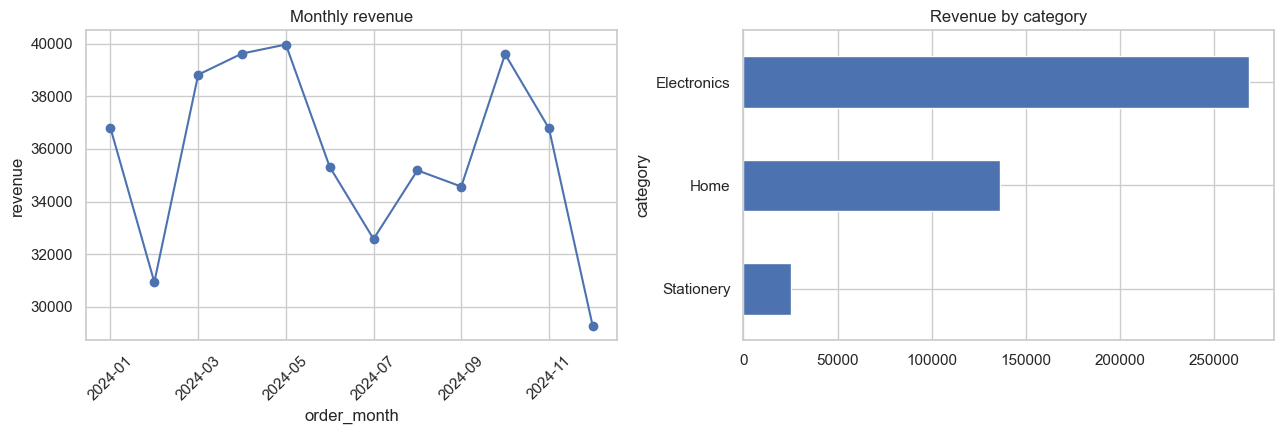

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

monthly = clean.groupby("order_month")["revenue"].sum()
monthly.plot(marker="o", ax=axes[0])
axes[0].set_title("Monthly revenue"); axes[0].set_ylabel("revenue")
axes[0].tick_params(axis="x", rotation=45)

cat = clean.groupby("category")["revenue"].sum().sort_values()
cat.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Revenue by category")
plt.tight_layout(); plt.show()

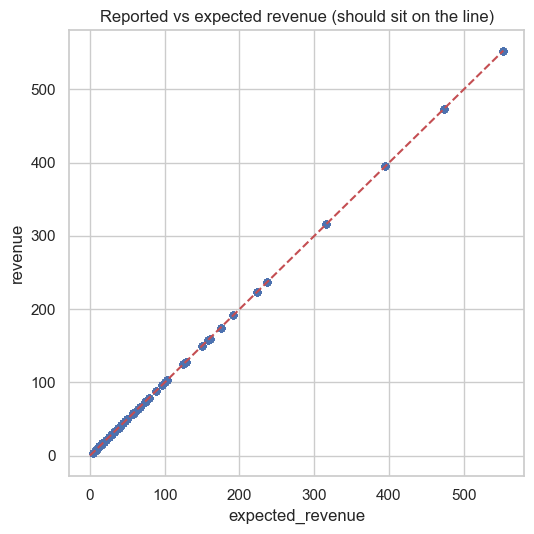

In [9]:
# sanity check: reported revenue should track expected (qty * unit_price)
ax = clean.plot.scatter(x="expected_revenue", y="revenue", alpha=0.2,
                        figsize=(5.5, 5.5))
lim = clean["expected_revenue"].max()
ax.plot([0, lim], [0, lim], "r--")
ax.set_title("Reported vs expected revenue (should sit on the line)")
plt.tight_layout(); plt.show()

## 4. Load — write analysis-ready Parquet

In [10]:
etl.load(clean, "../data/processed/sales_clean.parquet",
         "../data/processed/sales_clean_preview.csv")
reloaded = pd.read_parquet("../data/processed/sales_clean.parquet")
print("Reloaded from Parquet:", reloaded.shape)
print("dtypes preserved:", reloaded["order_date"].dtype, "|",
      reloaded["revenue"].dtype)
reloaded.head()

Reloaded from Parquet: (4900, 11)
dtypes preserved: datetime64[ns] | float64


,order_id,order_date,order_month,product_id,product_name,category,region,quantity,unit_price,revenue,expected_revenue
0,104608,2024-01-01,2024-01,P01,Wireless Mouse,Electronics,South,5,24.99,124.95,124.95
1,104242,2024-01-01,2024-01,P07,Mechanical Keyboard,Electronics,West,1,79.00,79.00,79.00
2,102704,2024-01-01,2024-01,P05,Water Bottle,Home,West,6,14.75,88.50,88.50
3,103410,2024-01-01,2024-01,P05,Water Bottle,Home,West,1,14.75,14.75,14.75
4,103171,2024-01-01,2024-01,P07,Mechanical Keyboard,Electronics,East,7,79.00,553.00,553.00


## Summary

| stage | what happened |
|-------|---------------|
| Extract | read 5,080 raw rows + product reference table |
| Transform | parsed dates/money, normalised text, removed duplicates & invalid rows, imputed regions, joined products, derived fields |
| Load | wrote a typed, analysis-ready Parquet file |

The same pipeline can be run end-to-end with `python src/etl.py`. Because the logic is
factored into small, testable functions, it's easy to schedule (cron / Airflow) or
point at a real data source.

**Possible extensions:** unit tests for each `clean_*` helper, schema validation with
`pandera`, partitioned Parquet by `order_month`, and incremental loads.